# Wine Quality Classification

### Overview
The Wine Quality Classification project involves analyzing the Wine Quality dataset to classify wine samples into different quality categories based on various physicochemical properties. This dataset is used to demonstrate classification techniques and evaluate model performance.

### Dataset
The Wine Quality dataset is available from the UCI Machine Learning Repository. It contains data on wine samples with features such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol, along with a target label indicating the wine quality (on a scale of 0 to 10).

### Objectives

1. **Data Exploration and Preprocessing:**
   - Load the Wine Quality dataset.
   - Inspect the dataset for missing values and basic statistics.
   - Visualize the distribution of features and quality ratings.

2. **Exploratory Data Analysis (EDA):**
   - Analyze the distribution of each feature.
   - Visualize the relationships between features and quality.
   - Check for correlations between features.

3. **Model Building and Evaluation:**
   - Split the dataset into training and testing sets.
   - Build classification models using algorithms like Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM).
   - Evaluate model performance using accuracy, confusion matrix, and classification report.

4. **Model Tuning:**
   - Fine-tune hyperparameters to improve model performance.
   - Use cross-validation to assess model stability.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

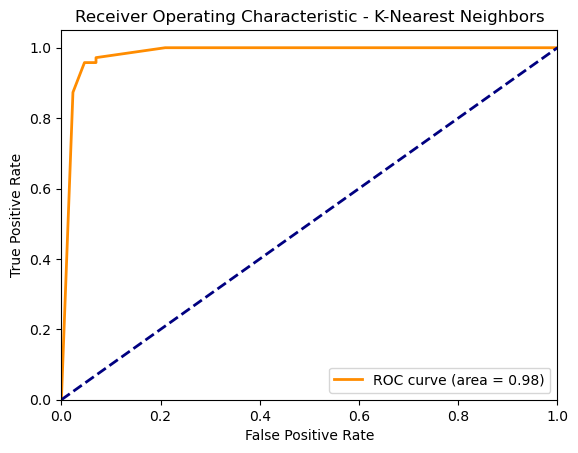


Support Vector Machine Performance:
Accuracy: 0.98
Confusion Matrix:
[[41  2]
 [ 0 71]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



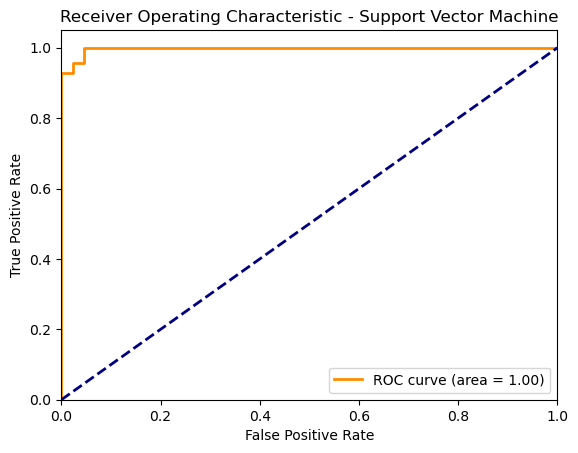


Logistic Regression Performance:
Accuracy: 0.97
Confusion Matrix:
[[41  2]
 [ 1 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



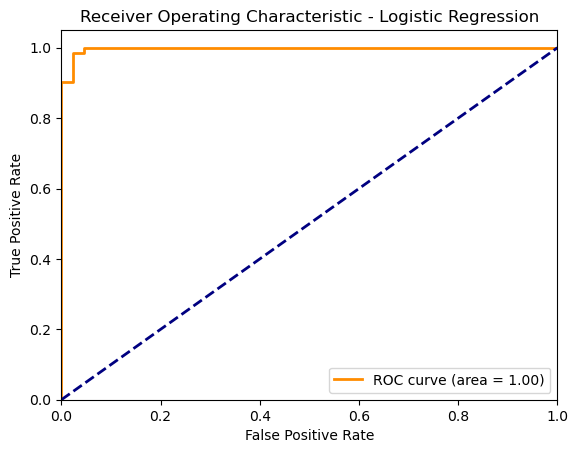

In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display basic information about the dataset
print(df.head())
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Split the dataset into features and target
X = df.drop('target', axis=1)
y = df['target']

# Ensure y is a 1D array
y = np.ravel(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True),  # Enable probability estimates
    'Logistic Regression': LogisticRegression(max_iter=10000)
}

# Train and evaluate each model
for name, model in models.items():
    # Create a pipeline with StandardScaler and the model
    pipeline = make_pipeline(StandardScaler(), model)
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluate performance
    print(f'\n{name} Performance:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # ROC Curve (for binary classification only)
    if len(np.unique(y)) == 2:
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc='lower right')
        plt.show()
